$$\Large Howards\,\, Simulation$$

$$\large defining\,\, erodability\,\,field$$

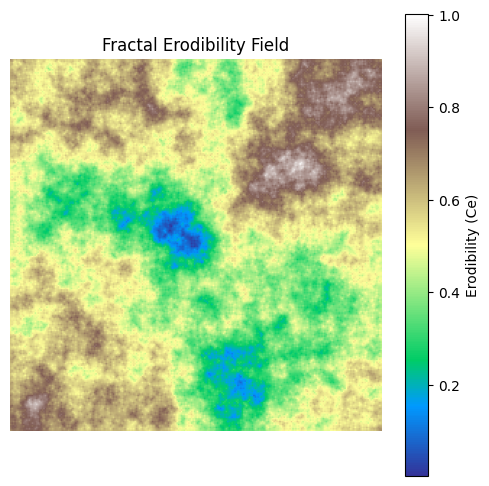

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def diamond_square(size, roughness=0.5, seed=None):
    
    if seed is not None:
        np.random.seed(seed)

    grid = np.zeros((size, size))
    step = size - 1
    grid[0, 0] = grid[0, -1] = grid[-1, 0] = grid[-1, -1] = 0  

    scale = 1.0 

    while step > 1:
        half = step // 2

        # Diamond step
        for x in range(half, size - 1, step):
            for y in range(half, size - 1, step):
                avg = (grid[x - half, y - half] +
                       grid[x - half, y + half] +
                       grid[x + half, y - half] +
                       grid[x + half, y + half]) / 4.0
                grid[x, y] = avg + np.random.uniform(-scale, scale)

        # Square step
        for x in range(0, size, half):
            for y in range((x + half) % step, size, step):
                neighbors = []
                if x - half >= 0: neighbors.append(grid[x - half, y])
                if x + half < size: neighbors.append(grid[x + half, y])
                if y - half >= 0: neighbors.append(grid[x, y - half])
                if y + half < size: neighbors.append(grid[x, y + half])
                avg = np.mean(neighbors)
                grid[x, y] = avg #+ np.random.uniform(-scale, scale)

        step //= 2
        scale *= 2 ** (-roughness)

    grid -= grid.min()
    grid /= grid.max()
    grid += grid.mean()*0.004
    return grid

size = 257
erod = diamond_square(size, roughness=0.55, seed=7)

plt.figure(figsize=(6,6))
plt.imshow(erod, cmap='terrain', origin='lower')
plt.colorbar(label='Erodibility (Ce)')
plt.title('Fractal Erodibility Field')
plt.axis('off')
plt.show()


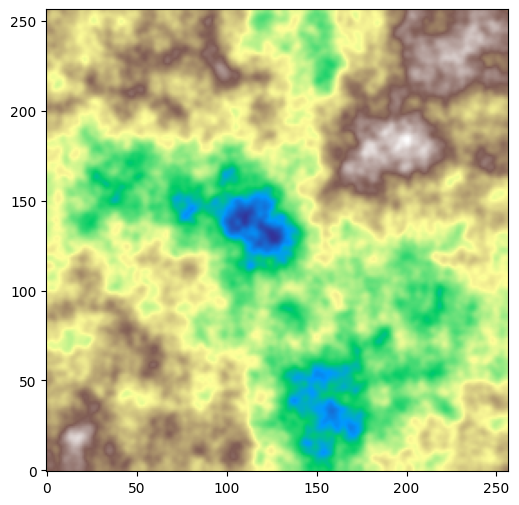

In [2]:
elevation=np.copy(erod)
from scipy.ndimage import gaussian_filter

elevation = gaussian_filter(elevation, sigma=1.2)
plt.figure(figsize=(6,6))
plt.imshow(elevation, cmap='terrain', origin='lower')
plt.show()

$$\large Backwasting\,\,in\,\,Mesas$$

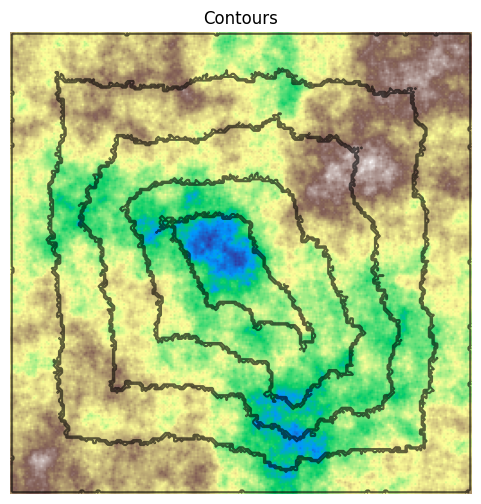

In [3]:
#parameters
time=500
threshold_randomness=0.5
damage_intensity=0.5
countor_levels=100
curvature_constant=0.3

Mount= np.ones((size-2, size-2))#size-2
mount = np.pad(Mount, pad_width=1, mode='constant', constant_values=2)
damage= np.zeros((size,size))#size
threshold = 1.0 + threshold_randomness * np.random.randn(size, size)
snapshots=[]



for dt in range(0,time):
    
        front = np.argwhere(mount == 2)
        for (x, y) in front:
            
            if mount[x][y]==2.0:
                if damage[x][y]>threshold[x][y]:
                    if x<size-1 and y<size-1:
                        if mount[x+1][y]==1: mount[x+1][y]=2
                        if mount[x][y+1]==1: mount[x][y+1]=2
                        if mount[x+1][y+1]==1: mount[x+1][y+1]=2    
                    if x>0 and y>0:                            
                        if mount[x-1][y]==1: mount[x-1][y]=2
                        if mount[x][y-1]==1: mount[x][y-1]=2
                        if mount[x-1][y-1]==1: mount[x-1][y-1]=2

                    if x>0 and y>0 and x<size-1 and y<size-1:      
                        if mount[x+1][y-1]==1: mount[x+1][y-1]=2
                        if mount[x-1][y+1]==1: mount[x-1][y+1]=2

                    mount[x][y]=0
                    
                else:
                    eroded_neighbors = 0
                    for dx in [-1, 0, 1]:
                        for dy in [-1, 0, 1]:
                            if (dx, dy) != (0, 0):
                                nx, ny = x + dx, y + dy
                                if 0 <= nx < size and 0 <= ny < size:
                                    if mount[nx, ny] == 0:  # eroded
                                        eroded_neighbors += 1

                    curvature = (eroded_neighbors - 4) / 4.0  
                    curvature_factor = 1 + curvature_constant * curvature      

                    damage[x][y] += erod[x][y] * damage_intensity * curvature_factor

                    
        if dt%countor_levels==0:
                snapshots.append(mount.copy())
                

plt.figure(figsize=(6,6))
plt.imshow(erod, cmap='terrain', origin='lower')
for i, m in enumerate(snapshots):
    plt.contour(m, levels=[1.5], colors=['black'], alpha=0.6)
plt.title('Contours')
plt.axis('off')
plt.show()

$$\large Backwasting\,\,model\,\, of \,\, western \,\, ghats$$

In [4]:
#parameters
time=700
threshold_randomness=0.5
damage_intensity=0.75
countor_levels=100
curvature_constant=0.3

Mount= np.ones((size, size-1))
trans=Mount.T 
trans[0]=np.ones((1,size))*2
mount = trans.T
damage= np.zeros((size,size))#size
threshold = 1.0 + threshold_randomness * np.random.randn(size, size)
snapshots=[]



for dt in range(0,time):
    
        front = np.argwhere(mount == 2)
        for (x, y) in front:
            
            if mount[x][y]==2.0:
                if damage[x][y]>threshold[x][y]:
                    if x<size-1 and y<size-1:
                        if mount[x+1][y]==1: mount[x+1][y]=2
                        if mount[x][y+1]==1: mount[x][y+1]=2
                        if mount[x+1][y+1]==1: mount[x+1][y+1]=2    
                    if x>0 and y>0:                            
                        if mount[x-1][y]==1: mount[x-1][y]=2
                        if mount[x][y-1]==1: mount[x][y-1]=2
                        if mount[x-1][y-1]==1: mount[x-1][y-1]=2

                    if x>0 and y>0 and x<size-1 and y<size-1:      
                        if mount[x+1][y-1]==1: mount[x+1][y-1]=2
                        if mount[x-1][y+1]==1: mount[x-1][y+1]=2

                    mount[x][y]=0
                    
                else:
                    eroded_neighbors = 0
                    for dx in [-1, 0, 1]:
                        for dy in [-1, 0, 1]:
                            if (dx, dy) != (0, 0):
                                nx, ny = x + dx, y + dy
                                if 0 <= nx < size and 0 <= ny < size:
                                    if mount[nx, ny] == 0: 
                                        eroded_neighbors += 1

                    curvature = (eroded_neighbors - 4) / 4.0  
                    curvature_factor = 1 + curvature_constant * curvature      

                    damage[x][y] += erod[x][y] * damage_intensity * curvature_factor

                    
        if dt%countor_levels==0:
                snapshots.append(mount.copy())
                

plt.figure(figsize=(6,6))
plt.imshow(erod, cmap='terrain', origin='lower')
for i, m in enumerate(snapshots):
    plt.contour(m, levels=[1.5], colors=['black'], alpha=0.6)
plt.title('Contours')
plt.axis('off')
plt.show()

IndexError: index 256 is out of bounds for axis 1 with size 256

$$\large Fluvial$$

In [ ]:
from collections import deque

def slop(ele, dx,dy): 
      zx,zy= np.gradient(ele,dx,dy)
      slope= np.sqrt(zx**2 + zy**2)
      return slope
    
def Q(ele):
    flowto = -np.ones((size, size, 2), dtype=int)
    inflow=np.zeros((size,size))
    outflow=np.ones((size,size))
    Qx = np.ones((size, size))

    for x in range(size):
       for y in range(size): 
         great, inx, iny = -10**12,0,0
         for dx in [-1, 0, 1]:
             for dy in [-1, 0, 1]:
                if (dx, dy) != (0, 0):
                    nx, ny = x + dx, y + dy
                    if 0 <= nx < size and 0 <= ny < size:
                        if dx==0 or dy==0:
                            slope= ele[x,y] - ele[nx,ny]
                            if great<slope:
                                great=slope
                                inx,iny=nx,ny
                        else:
                            slope= (ele[x,y] - ele[nx,ny])/1.414
                            if great<slope:
                                great=slope
                                inx,iny=nx,ny
         if great>0:
                inflow[inx,iny]+=1
                flowto[x,y]=[inx,iny]
         if great<0:
                outflow[x,y]=0
    
    que=deque()
    for x in range(size):
       for y in range(size): 
           if inflow[x,y]==0:
               que.append((x,y))

    while que:
        x,y = que.popleft()
        nx, ny = flowto[x, y]
        if nx<0: continue
        Qx[nx,ny] += Qx[x,y]
        inflow[nx,ny] -=1
        if inflow [nx,ny]==0:
            que.append((nx,ny))

    return Qx

In [ ]:
from scipy.ndimage import laplace
D = 0.001   # diffusion coefficient
Time=100
dx,dy= 1/6,1/6 #scaling
k,m,n=0.01,0.5,1  #stream power
alpha= 0.1
Acrit = 4     #thresholds/

for dt in range (Time):
    
    slope=slop(elevation,dx,dy)
    Acc=Q(elevation)
    
    E_flu=np.zeros((size,size))
    E_dif=np.zeros((size,size))
    
    E_diff=laplace(elevation)
    is_channel = (Acc >= Acrit)
    E_flu = k * (Acc**m) * (slope**n) * is_channel
    
    mask = elevation > 0
    elevation[mask] = elevation[mask] - (E_flu[mask]  + E_diff[mask]*D)*alpha

    if dt%10==0:
        print(dt,elevation.max())
    
plt.figure(figsize=(6,6))
plt.imshow(elevation, cmap='terrain', origin='lower')
plt.show()

In [ ]:
elevation.shape

X = Y= np.arange(0, 257, 1)

In [ ]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

surf = ax.plot_surface(X,Y, elevation, cmap="terrain")

In [ ]:
import plotly